# E36 · Multilevel regression and poststratification (MRP): what does every state think, from one survey?

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | 2018 Cooperative Congressional Election Study (CCES, 60,000 online respondents, YouGov), one policy question; a **poststratification table** of 228 million US adults in 12,000 state x ethnicity x sex x age x education cells built from the American Community Survey; state-level predictors (2016 Republican vote share, Census region) - all as prepared for Lopez-Martin, Phillips & Gelman's *MRP Case Studies* |
| **You will learn** | Why raw state means and simple weighting fail for small areas (tiny and empty cells, a skewed sample) · a multilevel logistic model with varying intercepts for state, age, education, ethnicity and three interactions · **zero-sum, non-centred** group effects and a **random-walk prior** on ordered groups · state-level predictors inside the state effect · prior predictive checks on the probability scale · fitting on **binomial cells** instead of 5,000 rows · **poststratification per posterior draw** for states and for subgroups within states · validation against a held-out 55,000-respondent benchmark, with coverage · a failure (no state predictors) that PSIS-LOO barely notices and the benchmark exposes · four displays for a lay audience: a value-suppressing tile map, "raw poll vs model" dot panels, an animated map of plausible worlds, icon arrays |

## The question, in one paragraph

About 5,000 Americans answer an online survey. One question asks whether employers should be
allowed to decline to cover abortions in their employees' health insurance. We want to know
what share of adults **in each of the 50 states** agree. The trouble: only six of the 5,000
live in Wyoming, ten in Delaware, and the people who answer online surveys are not a
miniature copy of the country (they are older and more educated, for a start). So we do two
things. First, we learn from *everyone* how opinion depends on age, education, ethnicity,
sex and the kind of state you live in - that tells us what, say, a college-educated woman in
her forties in a strongly Republican western state tends to think, even if we never met one
in Wyoming. Second, we use the Census to count how many people of each kind actually live in
each state, and add up. The result is an estimate for every state, with an honest statement
of how sure we can be - and, because the real survey asked 60,000 people, we can check our
answers against the 55,000 we held back.

## The technical version

**MRP** (Gelman & Little 1997; Park, Gelman & Bafumi 2004) is the standard tool for
small-area estimation of opinion from national surveys. It has two steps:

1. **Multilevel regression.** Model the probability of a "yes" for a person as a function of
   their demographic-geographic *cell* (state x ethnicity x sex x age x education), with
   partially pooled (multilevel) effects, so that cells with few or no respondents borrow
   strength from similar cells.
2. **Poststratification.** For each posterior draw, weight the model's cell probabilities by
   the number of people in each cell in the population (from the Census) to get any
   population quantity you like: a state, a subgroup within a state, the nation.

The second step corrects for a non-representative sample, provided the cells capture the
ways in which the sample differs from the population *and* in which opinion varies. The
first step makes the second possible when most cells are empty. This notebook follows the
first chapter of Lopez-Martin, Phillips & Gelman's case study (the same data, the same
5,000-person subsample design and a very similar model), rebuilt in PyMC, then adds a
held-out benchmark, calibration checks and displays for a non-technical reader.

In [1]:
import json
import logging
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from IPython.display import HTML
from matplotlib import animation
from matplotlib.colors import TwoSlopeNorm, to_rgb
from matplotlib.patches import Circle, Rectangle
from scipy.special import expit

from pymc_challenges import data

RANDOM_SEED = 1010
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

# One hue per quantity: blue for the model (MRP), orange for raw survey numbers, green for the
# held-out benchmark, grey for context.
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86"


def stacked(da):
    """(chain, draw, ...) -> (sample, ...) NumPy array."""
    return da.stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The data

### 1.1 The survey

The 2018 CCES common content has 60,000 respondents. We read only the six columns the case
study uses and recode them the same way: the outcome is 1 for "support" of the statement
*"Allow employers to decline coverage of abortions in insurance plans"* and 0 for "oppose";
ethnicity is collapsed to White / Black / Hispanic / Other; age is cut into six groups;
"some college" and "associate degree" are merged, giving five education groups. Respondents
from Washington DC (not in the poststratification table) and the 63 who skipped the question
are dropped.

In [2]:
data.describe("cces2018")
raw = data.load("cces2018")

STATES = ["AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "ID", "IL", "IN", "IA",
          "KS", "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
          "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VT",
          "VA", "WA", "WV", "WI", "WY"]
STATE_FIPS = [1, 2, 4, 5, 6, 8, 9, 10, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27,
              28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 50,
              51, 53, 54, 55, 56]
STATE_NAMES = dict(zip(STATES, [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware",
    "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky",
    "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota", "Mississippi",
    "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey", "New Mexico",
    "New York", "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania",
    "Rhode Island", "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
    "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"]))
AGES = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
EDUCS = ["No HS", "HS", "Some college", "4-Year College", "Post-grad"]
ETHS = ["White", "Black", "Hispanic", "Other"]

cces = pd.DataFrame({
    "support": (raw.CC18_321d == 1).astype(float).where(raw.CC18_321d.notna()),
    "state": raw.inputstate.map(dict(zip(STATE_FIPS, STATES))),
    "male": (raw.gender == 1).astype(int),
    "eth": raw.race.map({1: "White", 2: "Black", 3: "Hispanic"}).fillna("Other"),
    "age": pd.cut(2018 - raw.birthyr, [0, 29, 39, 49, 59, 69, 120], labels=AGES).astype(str),
    "educ": raw.educ.map({1: "No HS", 2: "HS", 3: "Some college", 4: "Some college",
                          5: "4-Year College", 6: "Post-grad"}),
}).dropna().reset_index(drop=True)
del raw
print(f"{len(cces):,} respondents with an answer in the 50 states; "
      f"{cces.support.mean():.1%} support the statement")
cces.head()

cces2018: 60,000 respondents of the 2018 CCES online survey (YouGov). Only the columns the case study uses are read: CC18_321d (allow employers to decline coverage of abortions in insurance plans: 1 support, 2 oppose), inputstate (state FIPS), gender (1 male, 2 female), race (1 White, 2 Black, 3 Hispanic, 4-8 other groups), birthyr, educ (1 no HS ... 6 post-grad).
  source: Ansolabehere, Schaffner & Luks, Cooperative Congressional Election Study 2018: Common Content (Harvard Dataverse, doi:10.7910/DVN/ZSBZ7K), as redistributed with Lopez-Martin, Phillips & Gelman, 'Multilevel Regression and Poststratification Case Studies' (GitHub JuanLopezMartin/MRPCaseStudy).
  url:    https://raw.githubusercontent.com/JuanLopezMartin/MRPCaseStudy/master/data_public/chapter1/data/cces18_common_vv.csv.gz


59,810 respondents with an answer in the 50 states; 43.4% support the statement


,support,state,male,eth,age,educ
0,1.0,MD,0,Other,50-59,Some college
1,1.0,TN,0,White,40-49,HS
2,1.0,OH,0,White,60-69,Some college
3,0.0,CA,0,Other,70+,Post-grad
4,1.0,KY,0,White,40-49,HS


**The design.** Following the case study, we pretend we only have a typical national poll:
a random **5,000** respondents. The other ~55,000 are locked away as a **benchmark** that we
only open in section 5. Because the 5,000 are a simple random sample *of the CCES*, the
5,000 and the 55,000 have the same biases relative to the population - a fair test of
small-area estimation, not of the CCES itself.

In [3]:
sample_rows = rng.choice(len(cces), 5000, replace=False)
survey = cces.iloc[sample_rows].reset_index(drop=True)
holdout = cces.drop(index=cces.index[sample_rows]).reset_index(drop=True)
n_state = survey.groupby("state").size().reindex(STATES, fill_value=0)
print(f"survey {len(survey):,}, benchmark {len(holdout):,}")
print("respondents per state in the survey, smallest ten:", n_state.sort_values().head(10).to_dict())

survey 5,000, benchmark 54,810
respondents per state in the survey, smallest ten: {'WY': 6, 'AK': 9, 'DE': 10, 'ND': 13, 'RI': 14, 'SD': 15, 'VT': 18, 'HI': 21, 'NH': 24, 'NM': 27}


### 1.2 The population: a poststratification table

The poststratification table, built by the case study's authors from the American Community
Survey, counts the **adults** in every combination of state (50) x ethnicity (4) x sex (2) x
age (6) x education (5): 12,000 cells. The state-level table has the Republican share of the
two-party vote in 2016 and the Census region.

In [4]:
data.describe("mrp_poststrat")
data.describe("mrp_state_predictors")
post_table = data.load("mrp_poststrat")
post_table["male"] = (post_table.male > 0).astype(int)
state_df = data.load("mrp_state_predictors").set_index("state").loc[STATES]
print(f"{len(post_table):,} cells, {post_table.n.sum() / 1e6:.0f} million adults; "
      f"smallest state Wyoming {post_table[post_table.state == 'WY'].n.sum():,} adults")
state_df.head()

mrp_poststrat: Poststratification table: number of adults (n) in each of 12,000 cells of state (50, no DC) x ethnicity (White, Black, Hispanic, Other) x male (-0.5 female, +0.5 male) x age (6 groups) x education (5 groups).
  source: Lopez-Martin, Phillips & Gelman, MRP Case Studies (chapter 1), built from the US Census Bureau's American Community Survey.
  url:    https://raw.githubusercontent.com/JuanLopezMartin/MRPCaseStudy/master/data_public/chapter1/data/poststrat_df.csv
mrp_state_predictors: For each of the 50 states: Republican share of the two-party vote in the 2016 presidential election (repvote) and Census region (Northeast, South, North Central, West).
  source: Lopez-Martin, Phillips & Gelman, MRP Case Studies (chapter 1).
  url:    https://raw.githubusercontent.com/JuanLopezMartin/MRPCaseStudy/master/data_public/chapter1/data/statelevel_predictors.csv
12,000 cells, 228 million adults; smallest state Wyoming 432,512 adults


,repvote,region
state,,
AL,0.643741,South
AK,0.583857,West
AZ,0.518900,West
AR,0.642851,South
CA,0.338718,West


## 2 · Why raw state means and simple weighting fail

### 2.1 The sample is not the population

Compare the survey's make-up with the population's, one variable at a time.

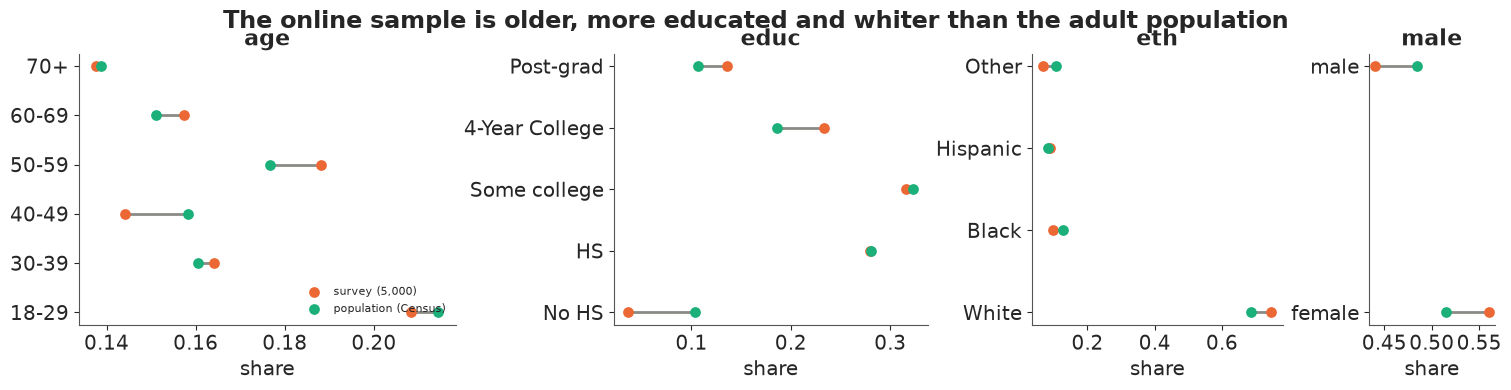

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), gridspec_kw={"width_ratios": [6, 5, 4, 2]})
for ax, col, levels in zip(axes, ["age", "educ", "eth", "male"], [AGES, EDUCS, ETHS, [0, 1]]):
    samp = survey[col].value_counts(normalize=True).reindex(levels, fill_value=0)
    pop = post_table.groupby(col).n.sum().reindex(levels)
    pop = pop / pop.sum()
    y = np.arange(len(levels))
    ax.hlines(y, samp, pop, color=GREY, lw=2)
    ax.scatter(samp, y, color=ORANGE, s=45, zorder=3, label="survey (5,000)")
    ax.scatter(pop, y, color=GREEN, s=45, zorder=3, label="population (Census)")
    ax.set_yticks(y, ["female", "male"] if col == "male" else levels)
    ax.set(xlabel="share", title=col)
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("The online sample is older, more educated and whiter than the adult population", y=1.04);

The survey has too many people aged 50-69, too many college graduates and too many women,
and too few people in their forties, people without a high-school diploma (a third of their
population share) and Black and "other" adults. If opinion differs across
those groups (it does, as we will see), the raw national mean is biased, and every raw state
mean is biased by its own amount.

### 2.2 Cells: most of the population lives where we met nobody

Weighting fixes a skewed sample by giving each respondent a weight equal to their cell's
population share divided by its sample share. At the level of state x ethnicity x sex x age x
education, that needs at least one respondent per cell.

In [6]:
KEYS = ["state", "eth", "male", "age", "educ"]
cells_survey = (survey.groupby(KEYS, observed=True).support.agg(["sum", "count"])
                .reset_index().rename(columns={"sum": "y", "count": "n"}))
merged = post_table.merge(cells_survey.rename(columns={"n": "n_resp"}), on=KEYS, how="left")
merged["hit"] = merged.n_resp.notna()
share_covered = merged[merged.hit].n.sum() / merged.n.sum()
by_state = merged.groupby("state").apply(lambda d: d[d.hit].n.sum() / d.n.sum(), include_groups=False)
print(f"{len(cells_survey):,} of 12,000 population cells contain at least one respondent")
print(f"they hold {share_covered:.0%} of US adults; by state from {by_state.min():.0%} "
      f"({by_state.idxmin()}) to {by_state.max():.0%} ({by_state.idxmax()})")

2,429 of 12,000 population cells contain at least one respondent
they hold 67% of US adults; by state from 7% (WY) to 84% (OH)


Full-cell weighting is impossible: in Wyoming the six respondents fall in cells that hold a
few percent of the state's adults, and the rest of the state has nobody to stand in for it.
The practical alternative is **raking** (iterative proportional fitting): find weights that
match the national margins of age, education, ethnicity and sex one at a time, then take a
weighted mean in each state. Raking corrects the national skew but still estimates Wyoming
from six people.

In [7]:
def rake(df, margins, n_iter=50):
    """Weights for the rows of df that match each target margin {column: Series of shares}."""
    w = np.ones(len(df))
    for _ in range(n_iter):
        for col, target in margins.items():
            current = pd.Series(w).groupby(df[col].to_numpy()).sum()
            current = current / current.sum()
            w *= (target / current).reindex(df[col]).to_numpy()
    return w / w.mean()


margins = {c: post_table.groupby(c).n.sum() / post_table.n.sum() for c in ["age", "educ", "eth", "male"]}
survey["w"] = rake(survey, margins)
raw_state = survey.groupby("state").support.mean().reindex(STATES)
raked_state = survey.groupby("state").apply(lambda d: np.average(d.support, weights=d.w),
                                            include_groups=False).reindex(STATES)
print(f"national: raw {survey.support.mean():.3f}, raked {np.average(survey.support, weights=survey.w):.3f}; "
      f"raking weights range {survey.w.min():.2f} to {survey.w.max():.2f}")
print("small states, raw -> raked:",
      {s: f"{raw_state[s]:.2f} -> {raked_state[s]:.2f} (n={n_state[s]})" for s in ["WY", "AK", "DE", "ND"]})

national: raw 0.425, raked 0.433; raking weights range 0.56 to 6.31
small states, raw -> raked: {'WY': '0.33 -> 0.42 (n=6)', 'AK': '0.44 -> 0.43 (n=9)', 'DE': '0.10 -> 0.10 (n=10)', 'ND': '0.23 -> 0.19 (n=13)'}


> **In plain words:** the people who answered are not a mini-America, and in small states we
> heard from only a handful of them. Re-weighting the answers fixes the first problem
> nationally, but it cannot invent information about Wyoming from six people: Delaware's raw
> figure, one supporter in ten respondents, is almost certainly not what Delaware thinks.

## 3 · The multilevel model

### 3.1 Structure

For a person in state $s$, ethnicity $r$, sex $m$ ($\pm 1/2$), age group $a$ and education $e$,

$$
\operatorname{logit} \Pr(\text{support}) = \beta_0 + \beta_{\text{male}}\, m
+ \alpha^{\text{state}}_s + \alpha^{\text{age}}_a + \alpha^{\text{educ}}_e + \alpha^{\text{eth}}_r
+ \alpha^{\text{male.eth}}_{m,r} + \alpha^{\text{educ.age}}_{e,a} + \alpha^{\text{educ.eth}}_{e,r},
$$

$$
\alpha^{\text{state}}_s = \gamma\, \text{repvote}_s + \alpha^{\text{region}}_{\text{region}[s]}
+ \sigma_{\text{state}}\, z_s .
$$

This is the case study's model with three changes, each a small modelling decision:

- **State-level predictors live inside the state effect.** Wyoming's intercept is centred on
  what its 2016 Republican vote share (standardised) and its region predict, and the
  residual $\sigma_{\text{state}} z_s$ is what the survey adds on top. With six respondents,
  the data say little and the prediction carries the estimate; with 450 Californians, the
  data dominate. This is where MRP gets its power for small areas (Lax & Phillips 2009;
  Buttice & Highton 2013).
- **Ordered groups get a random walk.** Age and education are ordered, so adjacent groups
  should be alike: $\alpha^{\text{age}}_{a+1} - \alpha^{\text{age}}_a \sim N(0, \sigma_{\text{age}})$,
  centred to sum to zero. It borrows along the ordering instead of towards the overall mean.
- **Everything is zero-sum and non-centred.** Each group effect is $\sigma \cdot z$ with $z$ a
  `pm.ZeroSumNormal` (for an interaction, zero-sum over both axes). Without the constraint,
  the intercept can trade off against the mean of every group, and the male main effect
  against the mean of the male x ethnicity interaction: in a prototype with plain `Normal`
  $z$'s nutpie reported tens (with state predictors) to hundreds (without) of divergences
  and $\hat{R}$ up to 1.10. With `ZeroSumNormal` the same model samples cleanly.

**Fitting on cells, not people.** Everyone in the same state x ethnicity x sex x age x
education cell has the same predicted probability, so the 5,000 Bernoulli rows collapse
exactly into about 2,400 binomial cells (successes out of respondents). The likelihood is the
same up to a constant; the gradient is cheaper, and it is the only way the 55,000-person
benchmark fits in a notebook budget. (LOO on cells leaves out a whole cell at a time; we
come back to that.)

In [8]:
cells_hold = (holdout.groupby(KEYS, observed=True).support.agg(["sum", "count"])
              .reset_index().rename(columns={"sum": "y", "count": "n"}))
REGIONS = sorted(state_df.region.unique())
region_idx = pd.Index(REGIONS).get_indexer(state_df.region)
repvote_z = ((state_df.repvote - state_df.repvote.mean()) / state_df.repvote.std()).to_numpy()


def cell_index(df):
    """Integer codes of the cell variables, in the model's level order."""
    ix = {"state": pd.Index(STATES).get_indexer(df.state), "eth": pd.Index(ETHS).get_indexer(df.eth),
          "age": pd.Index(AGES).get_indexer(df.age), "educ": pd.Index(EDUCS).get_indexer(df.educ),
          "male": df.male.to_numpy()}
    assert all((v >= 0).all() for v in ix.values())  # -1 would silently mean "the last level"
    return ix


def build_mrp(cells, state_preds=True, interactions=True, sd_scale=0.5, b0_scale=1.5):
    """The MRP logistic model on binomial cells (columns y, n and the five cell variables)."""
    ix = cell_index(cells)
    coords = {"state": STATES, "eth": ETHS, "age": AGES, "educ": EDUCS, "region": REGIONS,
              "sex": ["female", "male"], "cell": np.arange(len(cells))}
    with pm.Model(coords=coords) as model:
        b0 = pm.Normal("b0", 0, b0_scale)
        b_male = pm.Normal("b_male", 0, 1)

        def exchangeable(name, dims):
            sd = pm.HalfNormal(f"sd_{name}", sd_scale)
            z = pm.ZeroSumNormal(f"z_{name}", 1, dims=dims, n_zerosum_axes=len(dims))
            return sd * z

        def random_walk(name, dim):
            sd = pm.HalfNormal(f"sd_{name}", sd_scale)
            steps = pm.Normal(f"z_{name}", 0, 1, shape=len(coords[dim]) - 1)
            path = pt.concatenate([pt.zeros(1), pt.cumsum(sd * steps)])
            return pm.Deterministic(f"a_{name}", path - path.mean(), dims=dim)

        a_age = random_walk("age", "age")
        a_educ = random_walk("educ", "educ")
        a_eth = pm.Deterministic("a_eth", exchangeable("eth", ("eth",)), dims="eth")
        sd_state = pm.HalfNormal("sd_state", sd_scale)
        z_state = pm.ZeroSumNormal("z_state", 1, dims="state")
        a_state = sd_state * z_state
        if state_preds:
            g_repvote = pm.Normal("g_repvote", 0, 1)
            a_region = pm.Deterministic("a_region", exchangeable("region", ("region",)), dims="region")
            a_state = a_state + g_repvote * repvote_z + a_region[region_idx]
        a_state = pm.Deterministic("a_state", a_state, dims="state")
        eta = (b0 + b_male * (ix["male"] - 0.5) + a_state[ix["state"]] + a_age[ix["age"]]
               + a_educ[ix["educ"]] + a_eth[ix["eth"]])
        if interactions:
            a_me = pm.Deterministic("a_male_eth", exchangeable("male_eth", ("sex", "eth")), dims=("sex", "eth"))
            a_ea = pm.Deterministic("a_educ_age", exchangeable("educ_age", ("educ", "age")), dims=("educ", "age"))
            a_ee = pm.Deterministic("a_educ_eth", exchangeable("educ_eth", ("educ", "eth")), dims=("educ", "eth"))
            eta = eta + a_me[ix["male"], ix["eth"]] + a_ea[ix["educ"], ix["age"]] + a_ee[ix["educ"], ix["eth"]]
        pm.Binomial("y", n=cells.n.to_numpy(), logit_p=eta, observed=cells.y.to_numpy(), dims="cell")
    return model


EFFECTS = ["b0", "b_male", "a_state", "a_age", "a_educ", "a_eth", "a_male_eth", "a_educ_age", "a_educ_eth"]


def cell_logit(draws, ix):
    """Linear predictor for the cells in `ix` from a dict of draws (sample, ...) -> (sample, cell)."""
    eta = (draws["b0"][:, None] + draws["b_male"][:, None] * (ix["male"] - 0.5)
           + draws["a_state"][:, ix["state"]] + draws["a_age"][:, ix["age"]]
           + draws["a_educ"][:, ix["educ"]] + draws["a_eth"][:, ix["eth"]])
    if "a_male_eth" in draws:
        eta += (draws["a_male_eth"][:, ix["male"], ix["eth"]] + draws["a_educ_age"][:, ix["educ"], ix["age"]]
                + draws["a_educ_eth"][:, ix["educ"], ix["eth"]])
    return eta


def draws_of(group, n_keep=1000):
    """The effects needed for prediction, thinned to n_keep draws, as NumPy arrays."""
    out = {}
    for v in EFFECTS:
        if v in group:
            arr = stacked(group[v])
            out[v] = arr[:: max(1, len(arr) // n_keep)][:n_keep]
    return out


mrp_model = build_mrp(cells_survey)
print(f"{len(cells_survey):,} binomial cells from {cells_survey.n.sum():,} respondents; "
      f"{sum(v.size for v in mrp_model.initial_point().values())} unconstrained parameters")

2,429 binomial cells from 5,000 respondents; 110 unconstrained parameters


### 3.2 Poststratification as a matrix product

For each posterior draw, the estimate for a population group $G$ (a state, or a subgroup of
a state) is the population-weighted average of the cell probabilities,

$$
\theta_G = \frac{\sum_{j \in G} N_j\, \operatorname{logit}^{-1}(\eta_j)}{\sum_{j \in G} N_j},
$$

which for all groups at once is one matrix product: (draws x 12,000 cells) times a sparse
(12,000 x groups) matrix of population shares. Doing it **per draw** is what carries the
posterior uncertainty through; poststratifying the posterior mean of $\eta$ would not even
give the right point estimate, because the inverse logit is non-linear.

In [9]:
post_ix = cell_index(post_table)
N_cell = post_table.n.to_numpy().astype(float)


def poststrat_matrix(group_codes, n_groups):
    """(cell, group) matrix of within-group population shares."""
    W = np.zeros((len(post_table), n_groups))
    W[np.arange(len(post_table)), group_codes] = N_cell
    return W / W.sum(0, keepdims=True)


W_state = poststrat_matrix(post_ix["state"], 50)
W_nation = (N_cell / N_cell.sum())[:, None]


def poststratify(draws, W):
    """(sample, group) posterior of the population-weighted support."""
    return expit(cell_logit(draws, post_ix)) @ W

### 3.3 Prior predictive check on the probability scale

Priors on a logit scale are hard to judge by eye; what matters is what they imply for
probabilities. Draw from the prior and push the draws through the same poststratification:
what does the model believe, before seeing data, about one kind of person (a single cell)
and about a whole state? For contrast, a "vague" version with $\beta_0 \sim N(0, 5)$ and
every group sd $\sim$ HalfNormal(5).

weakly informative: sd ~ HalfNormal(0.5): P(cell prob < 0.02 or > 0.98) = 0.07; state support 90% prior range 0.07-0.95
vague: sd ~ HalfNormal(5), b0 ~ N(0, 5): P(cell prob < 0.02 or > 0.98) = 0.75; state support 90% prior range 0.03-0.98


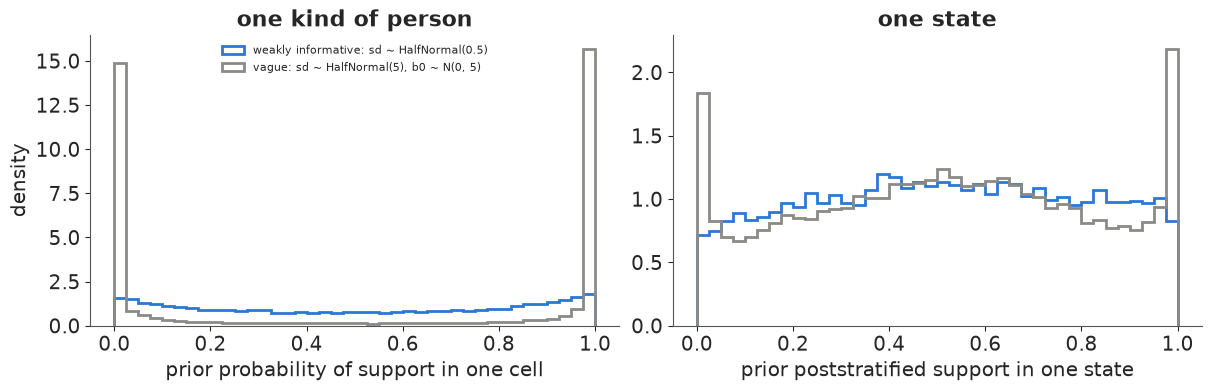

In [10]:
prior_draws = {}
for label, kw in [("weakly informative: sd ~ HalfNormal(0.5)", {}),
                  ("vague: sd ~ HalfNormal(5), b0 ~ N(0, 5)", {"sd_scale": 5.0, "b0_scale": 5.0})]:
    with build_mrp(cells_survey, **kw):
        prior = pm.sample_prior_predictive(draws=500, var_names=EFFECTS, random_seed=RANDOM_SEED)
    d = draws_of(prior.prior, 500)
    cell_p = expit(cell_logit(d, post_ix))
    prior_draws[label] = (cell_p[:, rng.choice(len(post_table), 40, replace=False)].ravel(),
                          (cell_p @ W_state).ravel())
    del cell_p

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for (label, (one_cell, one_state)), color in zip(prior_draws.items(), [BLUE, GREY]):
    axes[0].hist(one_cell, bins=np.linspace(0, 1, 41), density=True, histtype="step", lw=2, color=color, label=label)
    axes[1].hist(one_state, bins=np.linspace(0, 1, 41), density=True, histtype="step", lw=2, color=color, label=label)
    print(f"{label}: P(cell prob < 0.02 or > 0.98) = {np.mean((one_cell < 0.02) | (one_cell > 0.98)):.2f}; "
          f"state support 90% prior range {np.quantile(one_state, 0.05):.2f}-{np.quantile(one_state, 0.95):.2f}")
axes[0].set(xlabel="prior probability of support in one cell", ylabel="density", title="one kind of person")
axes[1].set(xlabel="prior poststratified support in one state", title="one state")
axes[0].legend(fontsize=8, loc="upper center");

The weakly informative prior spreads a single cell's probability over the whole range (only
about 7% of prior cell probabilities are below 2% or above 98%) and a state's support almost
uniformly between 0.07 and 0.95: open-minded, but it does not believe in whole demographic
groups that unanimously agree. The "vague" prior puts three quarters of the cells below 2%
or above 98% - it believes in groups where everybody or nobody agrees, which is exactly what
a small cell with 2 "yes" out of 2 will then seem to confirm - and even whole states pile
up at 0% and 100%, which nobody believes about a policy question. The sd scale of 0.5 is on
the logit scale, where 0.5 moves a probability near one half by about 12 percentage points.

## 4 · Fit, diagnose, poststratify

### 4.1 Sampling

In [11]:
with mrp_model:
    idata = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
    pm.compute_log_likelihood(idata, progressbar=False)

SD_VARS = ["sd_state", "sd_region", "sd_age", "sd_educ", "sd_eth", "sd_male_eth", "sd_educ_age", "sd_educ_eth"]
summ = az.summary(idata, var_names=["b0", "b_male", "g_repvote", *SD_VARS], round_to=2)
full_summ = az.summary(idata)
print(f"sampler nutpie, tuning steps {idata.posterior.attrs.get('tuning_steps')}, "
      f"divergences {int(idata.sample_stats['diverging'].sum())}, max r_hat {full_summ.r_hat.max():.3f}, "
      f"min bulk ESS {full_summ.ess_bulk.min():.0f}, min tail ESS {full_summ.ess_tail.min():.0f}")
summ

sampler nutpie, tuning steps 400, divergences 0, max r_hat 1.004, min bulk ESS 853, min tail ESS 877


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0,-0.46,0.06,-0.56,-0.36,2835.64,3071.05,1.0,0.0,0.00
b_male,0.25,0.09,0.10,0.39,3289.02,3093.26,1.0,0.0,0.00
g_repvote,0.10,0.05,0.02,0.18,3508.27,2993.92,1.0,0.0,0.00
sd_state,0.10,0.06,0.02,0.20,852.72,877.31,1.0,0.0,0.00
sd_region,0.28,0.15,0.11,0.56,1029.68,1441.35,1.0,0.0,0.01
sd_age,0.20,0.09,0.09,0.36,1208.75,1749.68,1.0,0.0,0.00
sd_educ,0.28,0.13,0.13,0.52,1232.70,1631.97,1.0,0.0,0.00
sd_eth,0.34,0.16,0.15,0.65,1022.13,1328.20,1.0,0.0,0.00
sd_male_eth,0.17,0.14,0.02,0.43,1190.02,1214.53,1.0,0.0,0.00
sd_educ_age,0.12,0.06,0.03,0.22,1175.45,1153.43,1.0,0.0,0.00


No divergences, $\hat{R}$ at 1.00-1.01 everywhere and bulk ESS in the high hundreds or more
for every parameter. The estimates themselves tell a story:

- The group standard deviations are all a few tenths on the logit scale: ethnicity, education,
  region and age matter most. Men are more supportive than women (`b_male` about 0.25).
- A standard deviation more Republican vote share raises support by about 0.1 on the logit
  scale (`g_repvote`), and the leftover state variation `sd_state` is about 0.1 and uncertain
  - with 5,000 respondents the model cannot say much about states beyond what their politics
  and region predict.
- The three interaction sds are smaller (0.1-0.2) and their intervals reach down to almost
  zero: 5,000 respondents say little about them. They cost little and matter for subgroup
  estimates when data are plentiful (Ghitza & Gelman 2013).

### 4.2 Posterior predictive check

The model predicts cell probabilities; the sample has cell counts. A direct check: for each
state and for each ethnicity x education group, compare the observed support *in the
survey* with the posterior predictive distribution of that same survey quantity (simulate
new counts in the observed cells and aggregate). Points should scatter around the diagonal
with most inside their 90% bars.

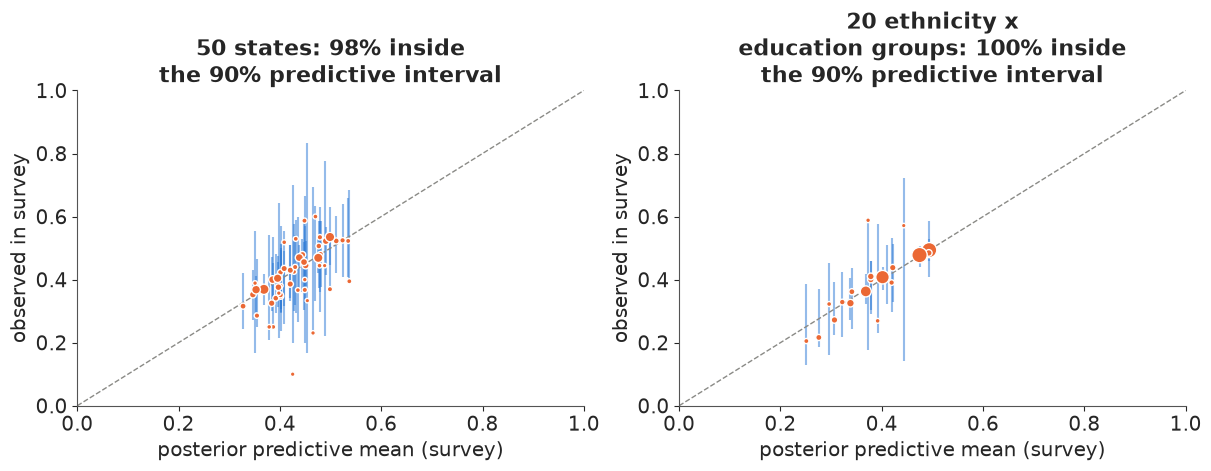

In [12]:
with mrp_model:
    ppc = pm.sample_posterior_predictive(idata.isel(draw=slice(None, None, 4)), random_seed=RANDOM_SEED,
                                         progressbar=False)
y_rep = stacked(ppc.posterior_predictive["y"])  # (1000, cell)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, keys, title in [(axes[0], ["state"], "50 states"), (axes[1], ["eth", "educ"], "20 ethnicity x\neducation groups")]:
    g = cells_survey.groupby(keys).ngroup().to_numpy()
    G = np.zeros((len(cells_survey), g.max() + 1))
    G[np.arange(len(g)), g] = 1
    n_g = cells_survey.n.to_numpy() @ G
    obs = cells_survey.y.to_numpy() @ G / n_g
    rep = y_rep @ G / n_g
    lo, hi = np.quantile(rep, [0.05, 0.95], axis=0)
    inside = np.mean((obs >= lo) & (obs <= hi))
    ax.vlines(rep.mean(0), lo, hi, color=BLUE, alpha=0.5)
    ax.scatter(rep.mean(0), obs, s=10 + n_g / 10, color=ORANGE, zorder=3, edgecolor="white")
    ax.plot([0, 1], [0, 1], color=GREY, lw=1, ls="--")
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="posterior predictive mean (survey)", ylabel="observed in survey",
           title=f"{title}: {inside:.0%} inside\nthe 90% predictive interval")
del ppc, y_rep

The observed survey means sit inside their predictive intervals even more often than the
nominal 90% (all but one state, all 20 groups). That is typical of an in-sample check: the
model was fitted to these very respondents, so it is optimistic. It rules out gross misfit
(no group is systematically off), but it checks the model against the data it saw, not
against the thing we care about, which is the population. Section 5 does that.

### 4.3 Poststratified state estimates

In [13]:
post = draws_of(idata.posterior)
theta = poststratify(post, W_state)          # (1000, 50): support in each state
theta_nat = poststratify(post, W_nation)[:, 0]
est = pd.DataFrame({
    "n": n_state, "raw": raw_state, "raked": raked_state,
    "mrp": theta.mean(0), "lo90": np.quantile(theta, 0.05, axis=0), "hi90": np.quantile(theta, 0.95, axis=0),
}, index=STATES)
print(f"national support: MRP {theta_nat.mean():.3f} (90% {np.quantile(theta_nat, 0.05):.3f}-"
      f"{np.quantile(theta_nat, 0.95):.3f}); raw sample {survey.support.mean():.3f}")
print(f"state estimates from {est.mrp.min():.2f} ({est.mrp.idxmin()}) to {est.mrp.max():.2f} "
      f"({est.mrp.idxmax()}); raw means from {est.raw.min():.2f} to {est.raw.max():.2f}")
print(f"90% interval width: median {np.median(est.hi90 - est.lo90):.3f}, "
      f"largest {np.max(est.hi90 - est.lo90):.3f} ({(est.hi90 - est.lo90).idxmax()})")

national support: MRP 0.432 (90% 0.419-0.444); raw sample 0.425
state estimates from 0.34 (MA) to 0.54 (WV); raw means from 0.10 to 0.60
90% interval width: median 0.094, largest 0.148 (WY)


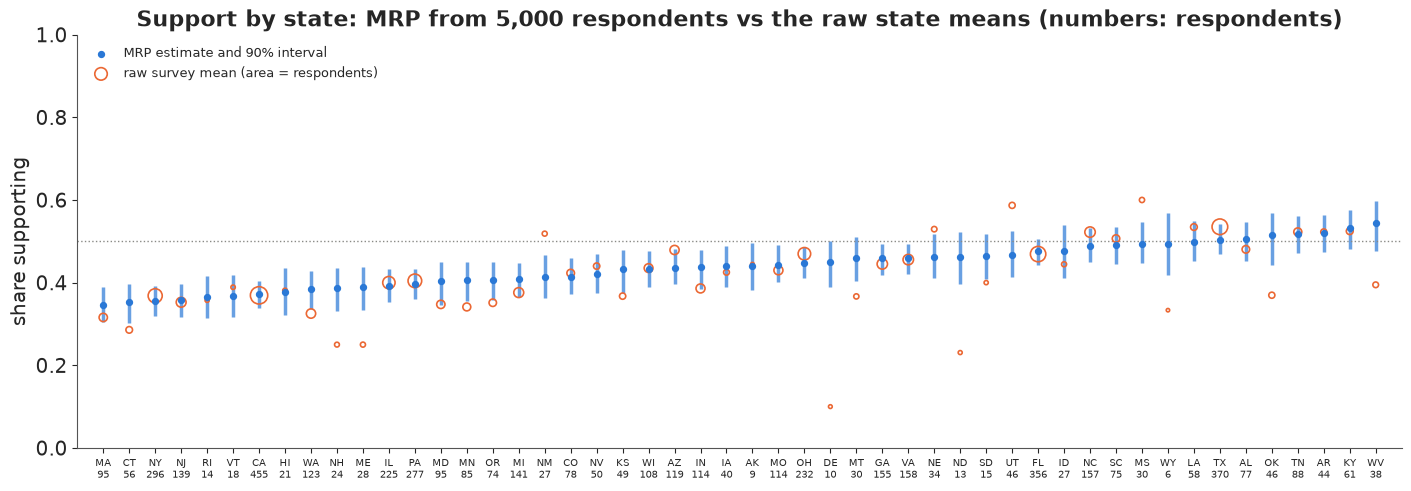

In [14]:
order = est.mrp.sort_values().index
x = np.arange(50)
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.vlines(x, est.lo90[order], est.hi90[order], color=BLUE, lw=2.5, alpha=0.7)
ax.scatter(x, est.mrp[order], color=BLUE, s=18, zorder=4, label="MRP estimate and 90% interval")
ax.scatter(x, est.raw[order], s=4 + est.n[order] / 3, facecolor="none", edgecolor=ORANGE, lw=1.2, zorder=3,
           label="raw survey mean (area = respondents)")
ax.axhline(0.5, color=GREY, lw=1, ls=":")
ax.set_xticks(x, [f"{s}\n{n}" for s, n in zip(order, est.n[order])], fontsize=7)
ax.set(ylabel="share supporting", xlim=(-1, 50), ylim=(0, 1),
       title="Support by state: MRP from 5,000 respondents vs the raw state means (numbers: respondents)")
ax.legend(loc="upper left", fontsize=9);

The raw means (orange circles) scatter from 10% to 60% because the small states' means
rest on a handful of people; the MRP estimates lie in a band from 35% to 54%,
ordered broadly by how Republican a state is, and the intervals are wider where we heard from
fewer people. Delaware's raw 10% becomes about 45%; Wyoming's raw 33% (2 of 6) becomes about
a half, because the model has learned that people like Wyoming's residents, in states like
Wyoming, tend to support the statement more than the national average.

> **In plain words:** the model gives every state a sensible answer - including states
> where we met only a few people - by learning from similar people everywhere and then
> counting who actually lives in each state. Where we have little direct evidence, it says
> so with a wider range.

### 4.4 Subgroups within states

The same draws poststratify to any subgroup. By age group within a few states: build a
(cell x state-age) share matrix and multiply.

P(support rises from 18-29 to 70+) by state: {'CA': '1.00', 'TX': '1.00', 'WY': '1.00', 'VT': '1.00'}


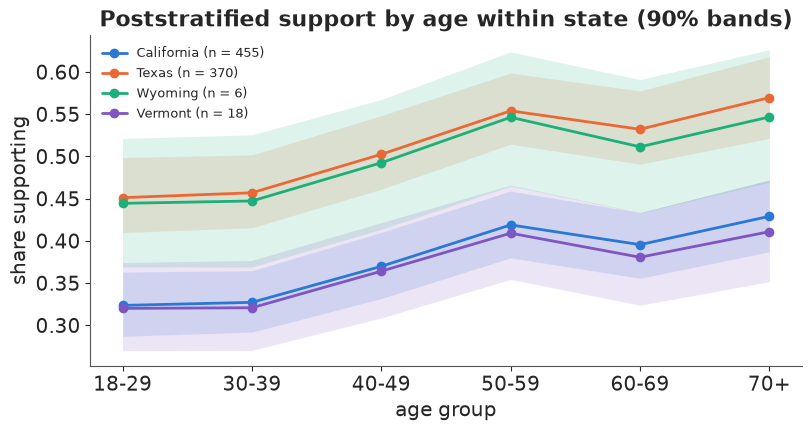

In [15]:
state_age = post_ix["state"] * len(AGES) + post_ix["age"]
theta_sa = poststratify(post, poststrat_matrix(state_age, 50 * len(AGES))).reshape(-1, 50, len(AGES))
show_states = ["CA", "TX", "WY", "VT"]
fig, ax = plt.subplots(figsize=(8, 4.2))
for s, c in zip(show_states, [BLUE, ORANGE, GREEN, "#7f55c2"]):
    i = STATES.index(s)
    lo, hi = np.quantile(theta_sa[:, i], [0.05, 0.95], axis=0)
    ax.fill_between(np.arange(6), lo, hi, color=c, alpha=0.15, lw=0)
    ax.plot(np.arange(6), theta_sa[:, i].mean(0), color=c, lw=2, marker="o", label=f"{STATE_NAMES[s]} (n = {n_state[s]})")
ax.set_xticks(np.arange(6), AGES)
ax.set(xlabel="age group", ylabel="share supporting", title="Poststratified support by age within state (90% bands)")
ax.legend(fontsize=9)
print("P(support rises from 18-29 to 70+) by state:",
      {s: f"{(theta_sa[:, STATES.index(s), -1] > theta_sa[:, STATES.index(s), 0]).mean():.2f}" for s in show_states})

The age pattern has the same *shape* in every state, because the model has no state x age
interaction; what differs is the level (Wyoming and Texas above California and Vermont)
and the composition within each age group, which the Census table supplies. That is an
assumption, not a finding: to let the age curve differ by state you would add a
state x age interaction, and 5,000 respondents would say very little about it.

## 5 · Validation: does MRP on 5,000 people match what 55,000 people say?

### 5.1 The benchmark

The case study compares the 5,000-person MRP with the full CCES. We do the same with the
**55,000 held-out** respondents (so the benchmark shares no one with the training sample).
Two benchmarks, answering two questions:

1. **The poststratified benchmark**: the same model fitted to the 55,000, poststratified.
   With 10 times the data per state, most of each state's estimate comes from its own
   respondents - this is our best guess of the truth, and "MRP-5k vs MRP-55k" asks how much
   we lose by having a small poll.
2. **The raw benchmark**: the plain share of held-out respondents in each state who support
   the statement. This does not depend on our model at all. The 5,000-person model can
   *predict* it exactly: weight its cell probabilities by the held-out sample's own cell
   counts and add binomial noise. If the model is calibrated, the observed held-out share
   lands inside the 90% predictive interval in about 45 of 50 states.

In [16]:
with build_mrp(cells_hold):
    idata_hold = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
hs = az.summary(idata_hold, var_names=["b_male", "g_repvote", "sd_state"], round_to=2)
hold_rhat = az.summary(idata_hold).r_hat
print(f"benchmark fit on {len(cells_hold):,} cells ({cells_hold.n.sum():,} people): divergences "
      f"{int(idata_hold.sample_stats['diverging'].sum())}, max r_hat {hold_rhat.max():.3f} ({hold_rhat.idxmax()}), "
      f"{(hold_rhat > 1.01).sum()} of {len(hold_rhat)} entries above 1.01:")
print(sorted({k.split("[")[0] for k in hold_rhat[hold_rhat > 1.01].index}))
bench_draws = poststratify(draws_of(idata_hold.posterior), W_state)
bench = bench_draws.mean(0)
# draws_of keeps chain order, so the 1000 thinned draws are 4 chains x 250: r_hat of the estimates
rhat_bench = az.rhat(xr.Dataset({"theta": (("chain", "draw", "state"), bench_draws.reshape(4, -1, 50))}))
print(f"max r_hat of the 50 poststratified benchmark estimates: {float(rhat_bench['theta'].max()):.3f}")
del idata_hold
hs

benchmark fit on 6,435 cells (54,810 people): divergences 0, max r_hat 1.032 (z_educ[3]), 17 of 263 entries above 1.01:
['sd_age', 'sd_educ', 'sd_eth', 'sd_region', 'z_age', 'z_educ', 'z_eth', 'z_region']


max r_hat of the 50 poststratified benchmark estimates: 1.008


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b_male,0.33,0.03,0.29,0.37,2666.82,3029.09,1.0,0.0,0.0
g_repvote,0.22,0.03,0.18,0.27,734.76,1230.69,1.0,0.0,0.0
sd_state,0.14,0.02,0.10,0.17,720.36,1554.45,1.0,0.0,0.0


The benchmark fit has no divergences, but 17 of its 263 parameters have $\hat{R}$ above 1.01
(up to about 1.03), all of them the sd and the standardised $z$ of the demographic main
effects (age, education, ethnicity, region). Each of those groups has only 4-6 levels, so
its sd is poorly determined however many people we ask, while 55,000 people pin down the
*effects* $\sigma z$ themselves very precisely: in the non-centred form the sampler must
then move $\sigma$ and $z$ together along a narrow ridge. This is the known flip side of
non-centring (with plenty of data per group the centred form mixes better; compare E25 and
E33). It does not affect what we use: the effects, and so the poststratified state
estimates, are well identified - their $\hat{R}$ is printed above.

mean absolute error vs the poststratified 55k benchmark, percentage points:
                   raw  raked  mrp  states
n                                         
< 30 respondents  12.9   12.8  3.8      14
30-100             4.7    5.6  2.7      19
> 100              4.1    3.6  2.5      17
all 50 states      6.8    6.9  2.9      50
benchmark's own posterior sd: median 1.5 points


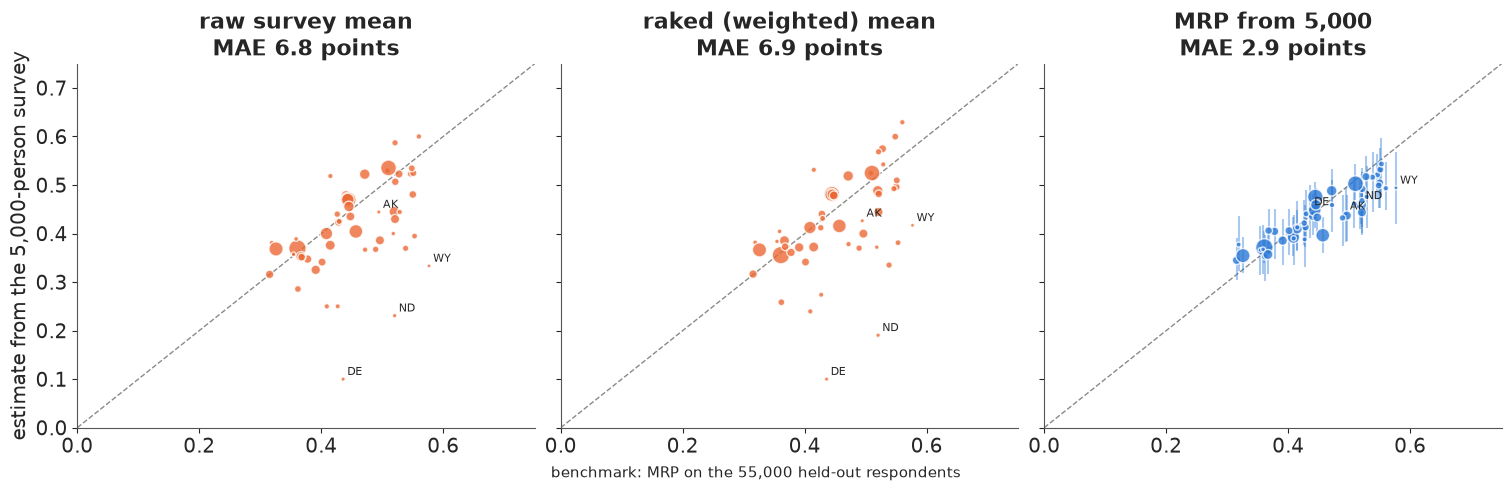

In [17]:
err = pd.DataFrame({m: est[m] - bench for m in ["raw", "raked", "mrp"]})
size = pd.cut(est.n, [0, 30, 100, 1000], labels=["< 30 respondents", "30-100", "> 100"])
mae = (err.abs().groupby(size, observed=True).mean() * 100).round(1)
mae.loc["all 50 states"] = (err.abs().mean() * 100).round(1)
mae["states"] = size.value_counts().reindex(mae.index[:-1]).tolist() + [50]
print("mean absolute error vs the poststratified 55k benchmark, percentage points:")
print(mae.to_string())
print(f"benchmark's own posterior sd: median {100 * np.median(bench_draws.std(0)):.1f} points")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for ax, m, color, label in [(axes[0], "raw", ORANGE, "raw survey mean"),
                            (axes[1], "raked", ORANGE, "raked (weighted) mean"),
                            (axes[2], "mrp", BLUE, "MRP from 5,000")]:
    ax.plot([0, 1], [0, 1], color=GREY, lw=1, ls="--")
    if m == "mrp":
        ax.vlines(bench, est.lo90, est.hi90, color=BLUE, alpha=0.4)
    ax.scatter(bench, est[m], s=6 + est.n / 3, color=color, alpha=0.8, edgecolor="white", zorder=3)
    for s in ["WY", "DE", "AK", "ND"]:
        ax.annotate(s, (bench[STATES.index(s)], est.loc[s, m]), fontsize=8, xytext=(3, 3), textcoords="offset points")
    ax.set(xlim=(0, 0.75), ylim=(0, 0.75), title=f"{label}\nMAE {100 * err[m].abs().mean():.1f} points")
axes[0].set_ylabel("estimate from the 5,000-person survey")
fig.supxlabel("benchmark: MRP on the 55,000 held-out respondents", fontsize=11);

From the same 5,000 people, the raw state means miss the benchmark by about 7 percentage
points on average and by more than 10 in the states with fewer than 30 respondents; raking
does not help the small states at all. MRP cuts the error to about 3 points everywhere, and
the small states - where it matters - improve the most. The points hug the diagonal but the
MRP cloud is *flatter* than the diagonal: the 5,000-person model shrinks states towards what
their politics predict a bit more than the 55,000-person benchmark does (compare
`sd_state` and `g_repvote` in the two fits). That is partial pooling working as designed on
less data, and it is the price of the variance reduction.

### 5.2 Calibration: predicting the raw held-out shares

held-out respondents per state: 88 to 4826
coverage of the held-out raw shares: 50% intervals 50%, 90% intervals 84%
states with PIT > 0.9: 11, < 0.1: 3; held-out raw share overall 0.435 vs survey 0.425
standardised errors: mean 0.43, sd 1.15; mean in the more Republican half 0.97, in the less Republican half -0.04


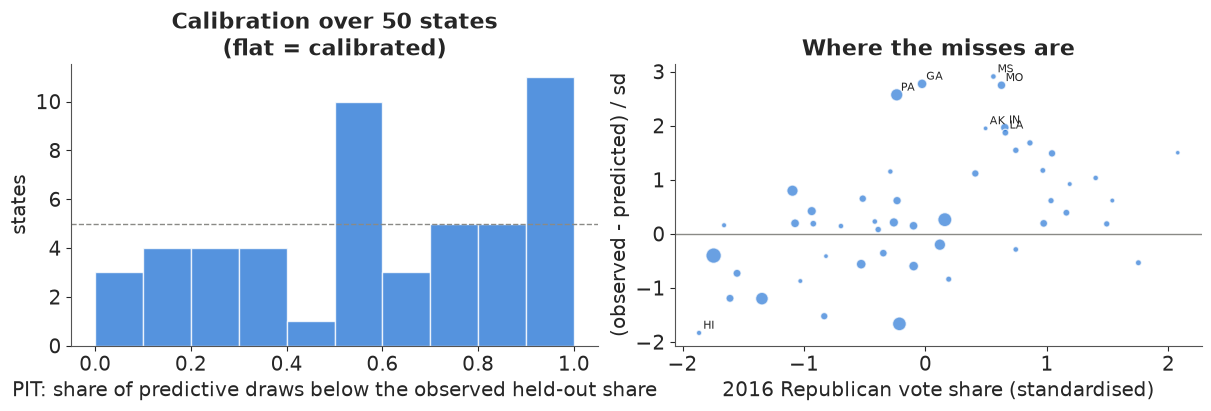

In [18]:
hold_ix = cell_index(cells_hold)
p_hold = expit(cell_logit(post, hold_ix))                    # (1000, held-out cell)
y_sim = rng.binomial(cells_hold.n.to_numpy()[None, :], p_hold)
S = np.zeros((len(cells_hold), 50))
S[np.arange(len(cells_hold)), hold_ix["state"]] = 1
n_hold = cells_hold.n.to_numpy() @ S
pred_raw = (y_sim @ S) / n_hold                              # predicted held-out share, per draw
obs_raw = (cells_hold.y.to_numpy() @ S) / n_hold
del p_hold, y_sim
pit = (pred_raw < obs_raw).mean(0)
cover = {q: np.mean(np.abs(pit - 0.5) <= q / 2) for q in [0.5, 0.9]}
print(f"held-out respondents per state: {n_hold.min():.0f} to {n_hold.max():.0f}")
print(f"coverage of the held-out raw shares: 50% intervals {cover[0.5]:.0%}, 90% intervals {cover[0.9]:.0%}")
print(f"states with PIT > 0.9: {(pit > 0.9).sum()}, < 0.1: {(pit < 0.1).sum()}; "
      f"held-out raw share overall {cells_hold.y.sum() / cells_hold.n.sum():.3f} vs survey {survey.support.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pit, bins=np.linspace(0, 1, 11), color=BLUE, alpha=0.8, edgecolor="white")
axes[0].axhline(5, color=GREY, ls="--", lw=1)
axes[0].set(xlabel="PIT: share of predictive draws below the observed held-out share",
            ylabel="states", title="Calibration over 50 states\n(flat = calibrated)")
z = (obs_raw - pred_raw.mean(0)) / pred_raw.std(0)
print(f"standardised errors: mean {z.mean():.2f}, sd {z.std():.2f}; mean in the more Republican half "
      f"{z[repvote_z > 0].mean():.2f}, in the less Republican half {z[repvote_z <= 0].mean():.2f}")
axes[1].scatter(repvote_z, z, s=10 + est.n / 4, color=BLUE, alpha=0.7, edgecolor="white")
for s in STATES:
    if abs(z[STATES.index(s)]) > 1.8:
        axes[1].annotate(s, (repvote_z[STATES.index(s)], z[STATES.index(s)]), fontsize=8, xytext=(3, 3),
                         textcoords="offset points")
axes[1].axhline(0, color=GREY, lw=1)
axes[1].set(xlabel="2016 Republican vote share (standardised)", ylabel="(observed - predicted) / sd",
            title="Where the misses are");

The 50% intervals cover half of the states, as they should, but the 90% intervals cover
only about 84%, and the PIT histogram is lopsided: in about 11 states the held-out share is
above the model's 90th percentile, in only 3 below its 10th. The misses are not random with
respect to politics: the standardised errors average about +1 in the more Republican half
of the states and about 0 in the other half (right panel). The 5,000-person model
**underestimates support in Republican states** - the flat cloud of 5.1 again: from 5,000
people it estimated the Republican-vote slope `g_repvote` at about 0.10, where the 55,000
say about 0.22. (A small part of the overall shift is luck of the draw: the 5,000 happen to
be about one point less supportive than the 55,000.) Honest remedies: a prior on
`g_repvote` informed by earlier surveys, or more state-level predictors (religiosity is the
classic one for abortion questions).

> **In plain words:** checked against 55,000 people it never saw, the model's state figures
> are typically within about 3 points of the truth, and its "9 in 10" ranges contain the
> answer in about 8 states out of 10. It is a little too sure of itself, and it leans too far
> towards the national average in the most Republican states.

## 6 · A failure: take away the state-level predictors

What does the state-level part of the model buy? Refit without `repvote` and region: states
are then exchangeable, and a state with six respondents is pulled towards the *national*
mean instead of towards what its politics predict. We also fit a version without the three
interactions, then compare all three with PSIS-LOO.

In [19]:
loo_results, theta_variants = {}, {}
loo_results["full model"] = az.loo(idata, pointwise=True)
for label, kw in [("no state predictors", {"state_preds": False}), ("no interactions", {"interactions": False})]:
    with build_mrp(cells_survey, **kw):
        idata_v = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
        pm.compute_log_likelihood(idata_v, progressbar=False)
    print(f"{label}: divergences {int(idata_v.sample_stats['diverging'].sum())}, "
          f"max r_hat {az.summary(idata_v).r_hat.max():.3f}, "
          f"sd_state {idata_v.posterior['sd_state'].mean().item():.2f}")
    theta_variants[label] = poststratify(draws_of(idata_v.posterior), W_state)
    loo_results[label] = az.loo(idata_v, pointwise=True)
    del idata_v
for res in loo_results.values():
    res.log_weights = None   # the (draw x cell) importance weights are the big part; not needed
del idata["log_likelihood"]
az.compare(loo_results, round_to=1)

no state predictors: divergences 0, max r_hat 1.006, sd_state 0.26


no interactions: divergences 0, max r_hat 1.007, sd_state 0.10


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
no interactions,0,0.0,0.0,NaN,,,26.1,-2219.0,25.7,0.6
full model,1,-0.3,2.4,0.5,|elpd_diff| < 4,,37.1,-2219.3,25.8,0.3
no state predictors,2,-5.2,4.5,0.9,,,49.7,-2224.2,25.7,0.1


errors in percentage points against the poststratified 55k benchmark:
                     MAE, < 30 resp.  MAE, all  90% covers benchmark  mean 90% width
no state predictors             6.95      4.67                  0.76           14.14
no interactions                 3.78      2.88                  0.82            9.72
full model                      3.78      2.94                  0.80            9.57


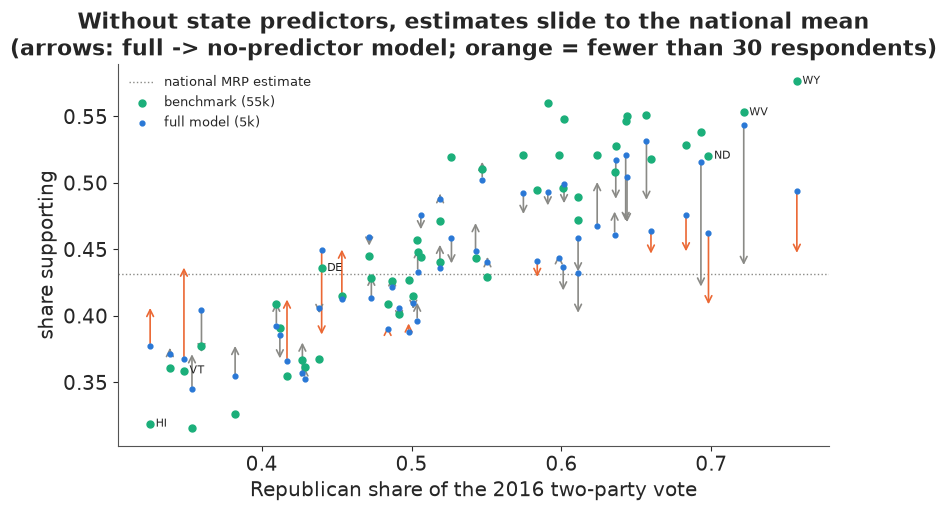

In [20]:
theta_variants["full model"] = theta
rows = {}
for label, th in theta_variants.items():
    e = th.mean(0) - bench
    lo, hi = np.quantile(th, [0.05, 0.95], axis=0)
    rows[label] = {"MAE, < 30 resp.": 100 * np.abs(e[est.n < 30]).mean(), "MAE, all": 100 * np.abs(e).mean(),
                   "90% covers benchmark": np.mean((bench >= lo) & (bench <= hi)),
                   "mean 90% width": 100 * (hi - lo).mean()}
print("errors in percentage points against the poststratified 55k benchmark:")
print(pd.DataFrame(rows).T.round(2).to_string())

nopred = theta_variants["no state predictors"].mean(0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(theta_nat.mean(), color=GREY, lw=1, ls=":", label="national MRP estimate")
for i, s in enumerate(STATES):
    ax.annotate("", xy=(state_df.repvote.iloc[i], nopred[i]), xytext=(state_df.repvote.iloc[i], est.mrp.iloc[i]),
                arrowprops=dict(arrowstyle="->", color=ORANGE if est.n.iloc[i] < 30 else GREY, lw=1.2))
ax.scatter(state_df.repvote, bench, color=GREEN, s=25, zorder=3, label="benchmark (55k)")
ax.scatter(state_df.repvote, est.mrp, color=BLUE, s=12, zorder=3, label="full model (5k)")
for s in ["WY", "DE", "ND", "VT", "HI", "WV"]:
    i = STATES.index(s)
    ax.annotate(s, (state_df.repvote.iloc[i], bench[i]), fontsize=8, xytext=(4, -2), textcoords="offset points")
ax.set(xlabel="Republican share of the 2016 two-party vote", ylabel="share supporting",
       title="Without state predictors, estimates slide to the national mean\n(arrows: full -> no-predictor model; orange = fewer than 30 respondents)")
ax.legend(fontsize=9, loc="upper left");

Without state-level predictors the small states collapse towards the national figure
(the arrows point at the dotted line), even though the benchmark shows a clear gradient with
Republican vote share: Wyoming, North Dakota and West Virginia are pushed down, Vermont and
Hawaii up. The small-state error nearly doubles (from about 4 to about 7 points). The model
compensates with a larger `sd_state` (about 0.26 instead of 0.1), so its intervals are wider,
but in the wrong place.

**And LOO barely notices.** The LOO difference between the full model and the no-predictor
model is a few points of elpd with a standard error of the same size, and the model without
interactions even comes out marginally on top. LOO scores how well each model predicts
*respondents in the sample*: the state-level predictors change the fit for a few dozen people
in small states and nothing for the 4,000 others. The poststratified estimates for a whole
state, which is what MRP is *for*, weight those few dozen people's cells by the whole
population of Wyoming. That is why MRP work validates against an external benchmark (or
against a previous election's known result) rather than relying on LOO alone. The
interactions change nothing visible in the state totals here; they matter for subgroup
estimates, and with deeper interactions and more data (Ghitza & Gelman 2013). A related
extension, **MrsP** (multilevel regression with *synthetic* poststratification; Leemann &
Wasserfallen 2017), lets you poststratify on variables whose joint distribution the Census
does not give, by combining their marginals.

> **In plain words:** a model that is not told how Republican each state is guesses that a
> small state is "average", and gets states like Wyoming and Vermont wrong in opposite
> directions. The usual statistical scorecard hardly sees the difference; only a check
> against real outside numbers reveals it.

## 7 · Explaining it to everyone

Four displays for a reader with no statistics - a journalist, a state legislator. Each uses
only numbers computed above, plain labels, and one idea per figure.

### 7.1 A tile map that fades where we are unsure

A tile map gives every state the same size, so Wyoming is as visible as California (on a
geographic map Wyoming's large area would exaggerate its weight, and Rhode Island would be
invisible). Colour follows a **value-suppressing palette** (Correll, Moritz & Heer 2018): as
a state's likely range widens, neighbouring colours merge and fade towards grey, so the map
refuses to draw distinctions the data cannot support.

states per certainty row (sure, less sure, unsure): [19 23  8]


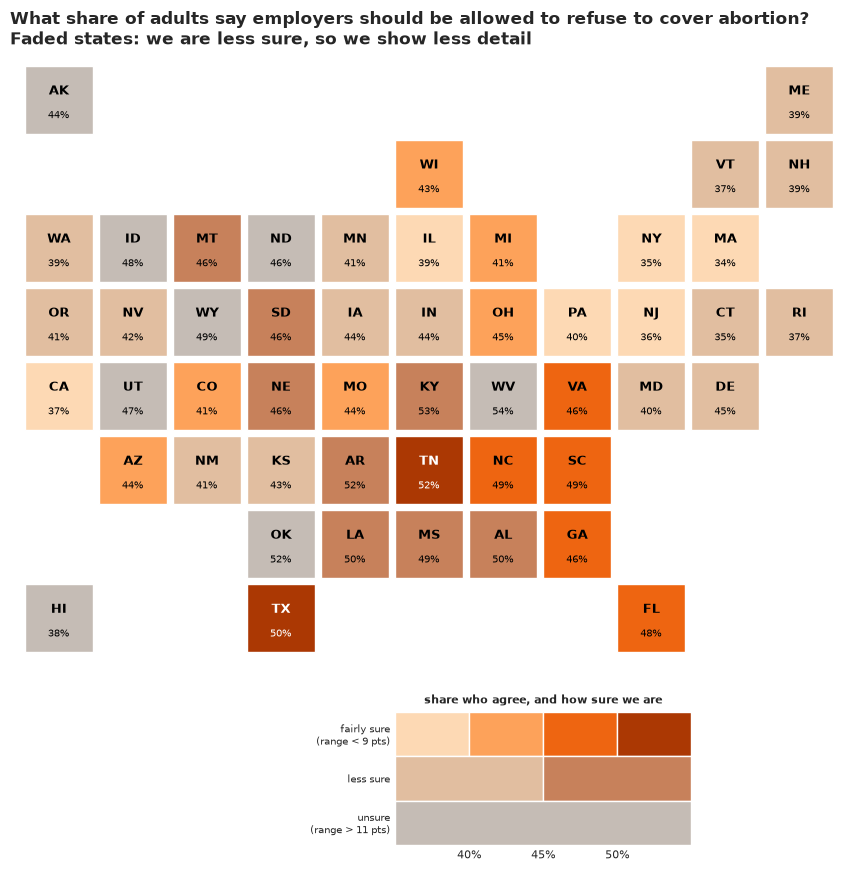

In [21]:
TILES = {"AK": (0, 0), "ME": (0, 10), "WI": (1, 5), "VT": (1, 9), "NH": (1, 10),
         "WA": (2, 0), "ID": (2, 1), "MT": (2, 2), "ND": (2, 3), "MN": (2, 4), "IL": (2, 5), "MI": (2, 6),
         "NY": (2, 8), "MA": (2, 9), "OR": (3, 0), "NV": (3, 1), "WY": (3, 2), "SD": (3, 3), "IA": (3, 4),
         "IN": (3, 5), "OH": (3, 6), "PA": (3, 7), "NJ": (3, 8), "CT": (3, 9), "RI": (3, 10),
         "CA": (4, 0), "UT": (4, 1), "CO": (4, 2), "NE": (4, 3), "MO": (4, 4), "KY": (4, 5), "WV": (4, 6),
         "VA": (4, 7), "MD": (4, 8), "DE": (4, 9), "AZ": (5, 1), "NM": (5, 2), "KS": (5, 3), "AR": (5, 4),
         "TN": (5, 5), "NC": (5, 6), "SC": (5, 7), "OK": (6, 3), "LA": (6, 4), "MS": (6, 5), "AL": (6, 6),
         "GA": (6, 7), "HI": (7, 0), "TX": (7, 3), "FL": (7, 8)}
assert sorted(TILES) == sorted(STATES)


def blend(color, w, grey=(0.75, 0.75, 0.75)):
    c = np.asarray(to_rgb(color))
    return tuple((1 - w) * c + w * np.asarray(grey))


def tile_map(ax, colors, labels=None, text_color=None, bottom=-7.2):
    for s, (r, c) in TILES.items():
        ax.add_patch(Rectangle((c, -r), 0.92, 0.92, facecolor=colors[s], edgecolor="white"))
        ax.text(c + 0.46, -r + 0.58, s, ha="center", va="center", fontsize=9, fontweight="bold",
                color=(text_color or {}).get(s, "black"))
        if labels:
            ax.text(c + 0.46, -r + 0.25, labels[s], ha="center", va="center", fontsize=7,
                    color=(text_color or {}).get(s, "black"))
    ax.set(xlim=(-0.2, 11.2), ylim=(bottom, 1.1), aspect="equal")
    ax.axis("off")


oranges = plt.get_cmap("Oranges")
VALUE_EDGES = [0.40, 0.45, 0.50]                       # four value bins
value_cols = [oranges(v) for v in (0.2, 0.42, 0.64, 0.86)]
width = (est.hi90 - est.lo90)
unc_edges = [0.09, 0.11]                              # 90% range narrower than 9 points: "sure"
vbin = np.digitize(est.mrp, VALUE_EDGES)
ubin = np.digitize(width, unc_edges)
vsup_rows = [[blend(c, 0.0) for c in value_cols],
             [blend(np.mean([value_cols[0], value_cols[1]], axis=0)[:3], 0.45),
              blend(np.mean([value_cols[2], value_cols[3]], axis=0)[:3], 0.45)],
             [blend(value_cols[1], 0.9)]]
vsup = {s: vsup_rows[u][v if u == 0 else (v // 2 if u == 1 else 0)] for s, u, v in zip(STATES, ubin, vbin)}
ink = {s: "white" if np.dot(to_rgb(c), [0.3, 0.59, 0.11]) < 0.5 else "black" for s, c in vsup.items()}
print("states per certainty row (sure, less sure, unsure):", np.bincount(ubin, minlength=3))

fig, ax = plt.subplots(figsize=(11, 8.6))
tile_map(ax, vsup, labels={s: f"{100 * est.mrp[s]:.0f}%" for s in STATES}, text_color=ink, bottom=-9.8)
ax.set_title("What share of adults say employers should be allowed to refuse to cover abortion?\n"
             "Faded states: we are less sure, so we show less detail", fontsize=12, loc="left")
lax = ax.inset_axes([5.0, -9.6, 4.0, 1.8], transform=ax.transData)
for r, row in enumerate(vsup_rows):
    w = 4 / len(row)
    for c, col in enumerate(row):
        lax.add_patch(Rectangle((c * w, 2 - r), w, 1, color=col, ec="white"))
lax.set(xlim=(0, 4), ylim=(0, 3))
lax.set_xticks([0, 1, 2, 3, 4], ["", "40%", "45%", "50%", ""], fontsize=8)
lax.set_yticks([2.5, 1.5, 0.5], ["fairly sure\n(range < 9 pts)", "less sure", "unsure\n(range > 11 pts)"], fontsize=7)
lax.tick_params(length=0)
for sp in lax.spines.values():
    sp.set_visible(False)
lax.set_title("share who agree, and how sure we are", fontsize=8);

**Why it works:** the reader gets the pattern (the South and the Mountain West above the
coasts) and, without reading a legend, which states to trust: the grey tiles (Alaska, Hawaii,
Idaho, North Dakota, Wyoming, Utah, Oklahoma, West Virginia) are all states where we heard
from 46 people or fewer. **What it hides:** the numbers printed on faded tiles
are still single best guesses, and the bins make 44% and 46% look different while 41% and
44% look the same. Nobody should read a state's rank off this map.

### 7.2 "What the poll said" vs "what the model says", for the smallest states

For each of the four states with the fewest respondents: every person we actually asked is
one dot (filled = agrees), next to the model's answer as **20 equally likely values** (a
quantile dotplot; Kay et al. 2016), and the answer from the 55,000 people we held back.

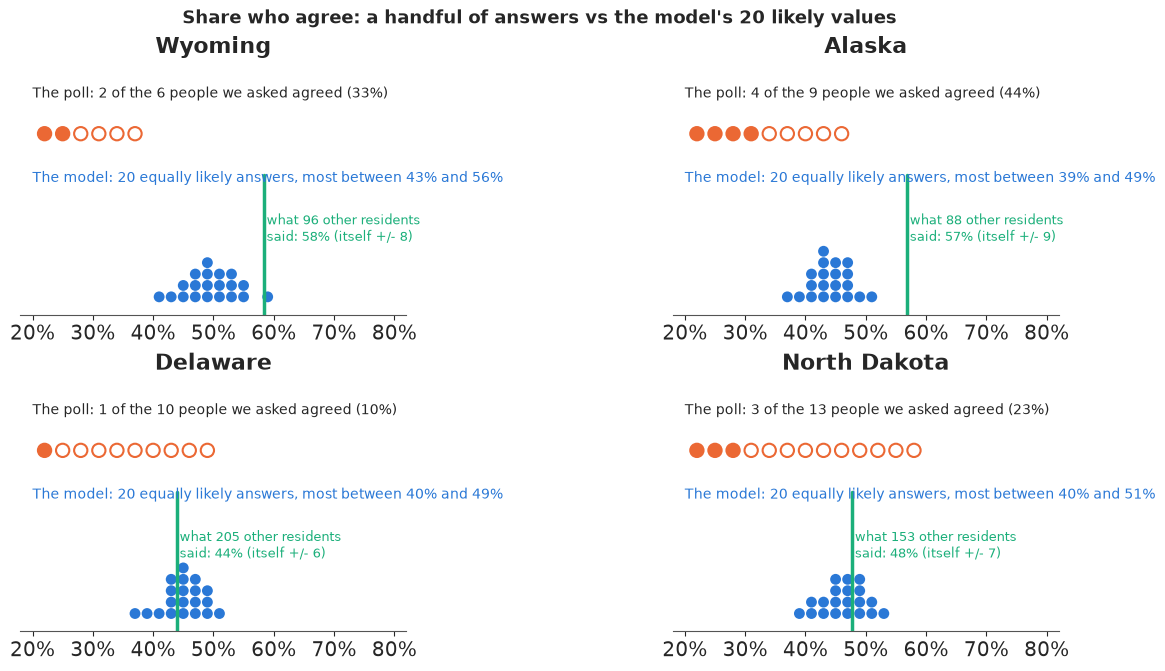

In [22]:
def quantile_dots(ax, samples, y0, n_dots=20, lo=0.2, hi=0.8, n_bins=30, color=BLUE, r=0.009):
    q = np.quantile(samples, (np.arange(n_dots) + 0.5) / n_dots)
    edges = np.linspace(lo, hi, n_bins + 1)
    col = np.clip(np.digitize(q, edges) - 1, 0, n_bins - 1)
    height = np.zeros(n_bins, int)
    for k in col:
        ax.add_patch(Circle((edges[k] + (edges[1] - edges[0]) / 2, y0 + (2 * height[k] + 1) * r * 1.05), r,
                            color=color, lw=0))
        height[k] += 1
    return q


small4 = est.n.sort_values().index[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 6.6))
for ax, s in zip(axes.flat, small4):
    i = STATES.index(s)
    answers = survey.loc[survey.state == s, "support"].to_numpy()
    for k, a in enumerate(sorted(answers, reverse=True)):
        ax.add_patch(Circle((0.22 + k * 0.03, 0.30), 0.011, facecolor=ORANGE if a else "white", edgecolor=ORANGE, lw=1.5))
    ax.text(0.2, 0.36, f"The poll: {int(answers.sum())} of the {len(answers)} people we asked agreed "
            f"({100 * answers.mean():.0f}%)", fontsize=10)
    q = quantile_dots(ax, theta[:, i], 0.02, lo=0.2, hi=0.8)
    ax.text(0.2, 0.22, f"The model: 20 equally likely answers, most between {100 * q[1]:.0f}% and {100 * q[-2]:.0f}%",
            fontsize=10, color=BLUE)
    ax.axvline(obs_raw[i], ymin=0, ymax=0.55, color=GREEN, lw=2.5)
    moe = 1.645 * np.sqrt(obs_raw[i] * (1 - obs_raw[i]) / n_hold[i])
    ax.text(obs_raw[i] + 0.005, 0.17, f"what {n_hold[i]:.0f} other residents\nsaid: {100 * obs_raw[i]:.0f}% "
            f"(itself +/- {100 * moe:.0f})",
            color=GREEN, fontsize=9, va="top")
    ax.set(xlim=(0.18, 0.82), ylim=(0, 0.42), aspect="equal", yticks=[], title=STATE_NAMES[s])
    ax.set_xticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], ["20%", "30%", "40%", "50%", "60%", "70%", "80%"])
    for sp in ["left", "right", "top"]:
        ax.spines[sp].set_visible(False)
fig.suptitle("Share who agree: a handful of answers vs the model's 20 likely values", fontsize=13);

**Why it works:** the reader can *count* the evidence - six dots is obviously not much - and
can count the model's answers too (the blue dots right of 50%, out of 20, are the chance of
a majority, without the word "probability"). The green line shows that the model can be
checked, and the check is honest rather than flattering: in Delaware and North Dakota the
other residents land in the middle of the blue dots, far from the raw poll; in Wyoming at
the upper edge; in Alaska well above them - the under-estimate in Republican-leaning states
found in section 5.2, although 88 Alaskans are themselves a small poll. **What it hides:**
why the model moved (it borrowed from similar people elsewhere) needs a sentence of
explanation, and the green line is a raw share, not adjusted for who answered.

### 7.3 One plausible America per frame

A hypothetical-outcome animation (Hullman, Resnick & Adar 2015): each frame is one draw from
the model - one internally consistent version of America that fits the survey. States
whose colour flickers are uncertain; states that stay put are not. The title counts how many
states have a majority agreeing in that world, which is a question a map of averages cannot
answer.

In [23]:
n_frames = 36
frame_draws = rng.choice(theta.shape[0], n_frames, replace=False)
seq = plt.get_cmap("PuOr_r")
norm = TwoSlopeNorm(vmin=0.30, vcenter=0.50, vmax=0.60)  # white exactly at 50%: orange = majority
majority = (theta > 0.5).sum(1)

fig, ax = plt.subplots(figsize=(9, 6.2), dpi=72)
tiles, tile_text = {}, {}
for s, (r, c) in TILES.items():
    tiles[s] = ax.add_patch(Rectangle((c, -r), 0.92, 0.92, facecolor="white", edgecolor="white"))
    tile_text[s] = ax.text(c + 0.46, -r + 0.46, s, ha="center", va="center", fontsize=9, fontweight="bold")
ax.set(xlim=(-0.2, 11.2), ylim=(-7.2, 1.1), aspect="equal")
ax.axis("off")
sm = plt.cm.ScalarMappable(norm=norm, cmap=seq)
cb = fig.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.5, pad=0.02)
cb.set_ticks([0.3, 0.4, 0.5, 0.6], labels=["30%", "40%", "50%", "60%"])
cb.set_label("share who agree (orange = majority agrees)")
title = ax.set_title("")
plt.close(fig)


def show_world(k):
    d = frame_draws[k]
    for i, s in enumerate(STATES):
        rgb = seq(norm(theta[d, i]))
        tiles[s].set_facecolor(rgb)
        tile_text[s].set_color("white" if np.dot(rgb[:3], [0.3, 0.59, 0.11]) < 0.45 else "black")
    title.set_text(f"Plausible world {k + 1} of {n_frames}: a majority agrees in {majority[d]} states")
    return list(tiles.values()) + list(tile_text.values()) + [title]


show_world(0)
hop = animation.FuncAnimation(fig, show_world, frames=n_frames, interval=500)
print(f"states with a majority agreeing, over all {theta.shape[0]} plausible worlds: median "
      f"{np.median(majority):.0f}, 90% range {np.quantile(majority, 0.05):.0f}-{np.quantile(majority, 0.95):.0f}; "
      f"P(no state has a majority) = {(majority == 0).mean():.2f}")
p_major = pd.Series((theta > 0.5).mean(0), index=STATES).sort_values()
print("P(majority agrees), states between 0.1 and 0.9:", p_major[(p_major > 0.1) & (p_major < 0.9)].round(2).to_dict())
print("P(majority agrees) for CA, NY, MA:", p_major[["CA", "NY", "MA"]].round(3).to_dict())
HTML(hop.to_jshtml(default_mode="loop"))

states with a majority agreeing, over all 1000 plausible worlds: median 8, 90% range 4-13; P(no state has a majority) = 0.00
P(majority agrees), states between 0.1 and 0.9: {'NE': 0.12, 'SD': 0.13, 'ND': 0.14, 'UT': 0.17, 'ID': 0.27, 'NC': 0.28, 'SC': 0.38, 'MS': 0.39, 'WY': 0.45, 'LA': 0.48, 'TX': 0.5, 'AL': 0.59, 'OK': 0.73, 'TN': 0.76, 'AR': 0.8, 'WV': 0.86, 'KY': 0.86}
P(majority agrees) for CA, NY, MA: {'CA': 0.0, 'NY': 0.0, 'MA': 0.0}


**Why it works:** uncertainty becomes something you watch rather than decode: Wyoming,
Texas, Louisiana and Mississippi flip between orange and purple from frame to frame (each
has a majority in 40-50% of the plausible worlds), while California, New York and
Massachusetts stay purple in every one of the 1,000. It
also answers joint questions ("how many states?") that no single-state range can. **What it
hides:** the eye tracks a few states and misses the rest, it cannot be printed, and a reader
who stops on one frame takes it for *the* answer - the frame counter and the word
"plausible" are there to prevent that.

### 7.4 Out of 100 adults

Frequency framing, borrowed from medical risk communication: 100 people, coloured by what
the model says. Solid orange figures agree in nearly every plausible world (the low end of
the 90% range); hatched figures are the ones the model is unsure about (the width of the
range); outlined figures disagree.

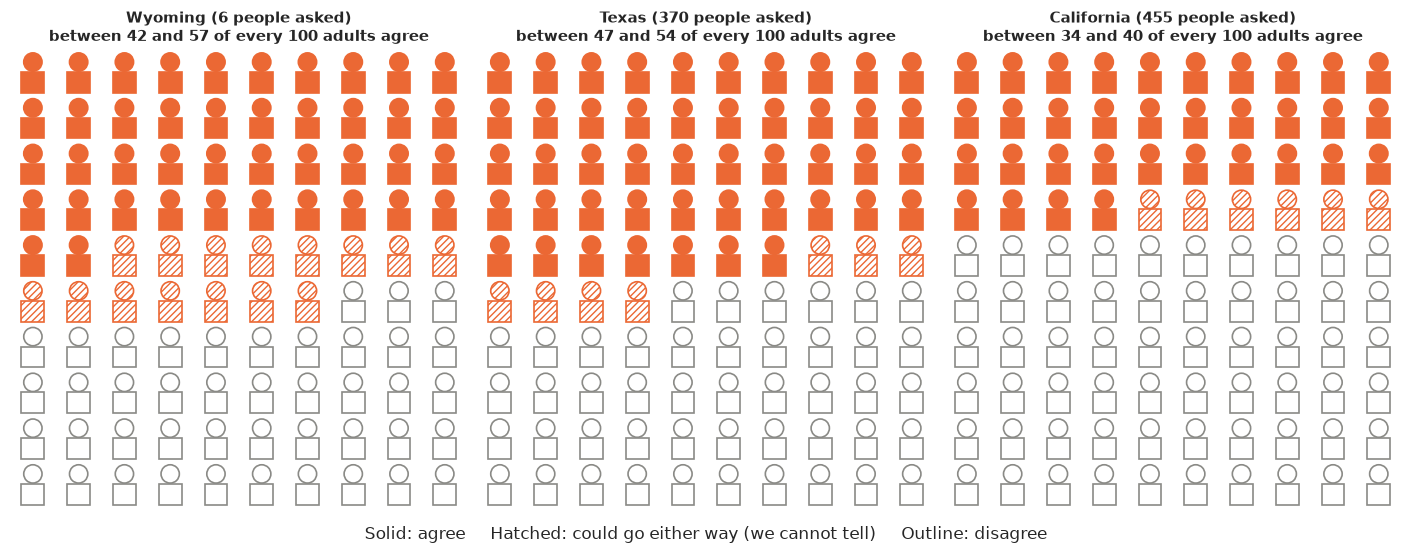

In [24]:
def icon_array(ax, lo, hi, name):
    n_lo, n_hi = int(round(100 * lo)), int(round(100 * hi))
    for k in range(100):
        x, y = k % 10, 9 - k // 10
        if k < n_lo:
            kw = dict(facecolor=ORANGE, edgecolor=ORANGE)
        elif k < n_hi:
            kw = dict(facecolor="white", edgecolor=ORANGE, hatch="/////")
        else:
            kw = dict(facecolor="white", edgecolor=GREY)
        ax.add_patch(Circle((x + 0.5, y + 0.72), 0.2, lw=1.2, **kw))            # head
        ax.add_patch(Rectangle((x + 0.25, y + 0.05), 0.5, 0.45, lw=1.2, **kw))   # body
    ax.set(xlim=(0, 10), ylim=(0, 10), aspect="equal", xticks=[], yticks=[])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(f"{name}\nbetween {n_lo} and {n_hi} of every 100 adults agree", fontsize=11)


fig, axes = plt.subplots(1, 3, figsize=(14, 5.4))
for ax, s in zip(axes, ["WY", "TX", "CA"]):
    icon_array(ax, est.lo90[s], est.hi90[s], f"{STATE_NAMES[s]} ({n_state[s]} people asked)")
fig.supxlabel("Solid: agree     Hatched: could go either way (we cannot tell)     Outline: disagree", fontsize=12);

**Why it works:** "between 42 and 57 of every 100" is a statement anyone can repeat, and the
hatched band makes the size of the uncertainty literal: 15 hatched figures in Wyoming, 6 in
California, because we asked 6 people in one and 455 in the other. **What it hides:**
the icons suggest a person-by-person split that the model does not claim (nobody is "hatched"
in reality), and the choice of a 90% range is a convention the reader has to be told.

## 8 · Export for the web page

In [25]:
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
keep = rng.choice(theta.shape[0], 200, replace=False)
wy = STATES.index("WY")
HEADLINES = {
    "national": (f"About {100 * theta_nat.mean():.0f}% of US adults agree that employers should be allowed to decline "
                 f"to cover abortion (likely range {100 * np.quantile(theta_nat, 0.05):.0f}-"
                 f"{100 * np.quantile(theta_nat, 0.95):.0f}%)."),
    "states": (f"State estimates run from about {100 * est.mrp.min():.0f}% in {STATE_NAMES[est.mrp.idxmin()]} to "
               f"{100 * est.mrp.max():.0f}% in {STATE_NAMES[est.mrp.idxmax()]}; in a typical plausible world a majority "
               f"agrees in {np.median(majority):.0f} states."),
    "wyoming": (f"Only {n_state['WY']} of the 5,000 people surveyed live in Wyoming ({int(survey[survey.state == 'WY'].support.sum())} "
                f"agreed), yet the model puts Wyoming at about {100 * est.mrp['WY']:.0f}% (likely range "
                f"{100 * est.lo90['WY']:.0f}-{100 * est.hi90['WY']:.0f}%); {n_hold[wy]:.0f} other Wyoming "
                f"respondents gave {100 * obs_raw[wy]:.0f}%."),
    "validation": (f"Checked against 55,000 respondents it never saw, the model's state figures were off by "
                   f"{100 * err['mrp'].abs().mean():.1f} points on average, against {100 * err['raw'].abs().mean():.1f} "
                   f"for the raw poll."),
    "failure": (f"Without knowing how Republican each state is, the model pulls small states to the national average "
                f"and its error in states with fewer than 30 respondents grows from "
                f"{rows['full model']['MAE, < 30 resp.']:.1f} to {rows['no state predictors']['MAE, < 30 resp.']:.1f} points."),
}
export = {
    "id": "E36",
    "title": "What does every state think, from one survey of 5,000 people?",
    "question": "Allow employers to decline coverage of abortions in insurance plans (share who agree, adults 18+)",
    "units": "share of adults (0-1)",
    "national": {"draws": np.round(theta_nat[keep], 4).tolist(),
                 "raw_sample": round(float(survey.support.mean()), 4)},
    "states": [{
        "abbr": s, "name": STATE_NAMES[s], "tile_row": TILES[s][0], "tile_col": TILES[s][1],
        "n_survey": int(n_state[s]), "n_agree_survey": int(survey[survey.state == s].support.sum()),
        "raw_survey": None if n_state[s] == 0 else round(float(est.raw[s]), 4),
        "median": round(float(np.median(theta[:, i])), 4),
        "q05": round(float(est.lo90[s]), 4), "q95": round(float(est.hi90[s]), 4),
        "q25": round(float(np.quantile(theta[:, i], 0.25)), 4), "q75": round(float(np.quantile(theta[:, i], 0.75)), 4),
        "p_majority": round(float((theta[:, i] > 0.5).mean()), 3),
        "benchmark_mrp_55k": round(float(bench[i]), 4), "benchmark_raw_55k": round(float(obs_raw[i]), 4),
        "n_benchmark": int(n_hold[i]), "no_state_predictor_median": round(float(np.median(theta_variants["no state predictors"][:, i])), 4),
        "draws": np.round(theta[keep, i], 3).tolist(),
        "by_age": {"groups": AGES, "q05": np.round(np.quantile(theta_sa[:, i], 0.05, axis=0), 3).tolist(),
                   "median": np.round(np.median(theta_sa[:, i], axis=0), 3).tolist(),
                   "q95": np.round(np.quantile(theta_sa[:, i], 0.95, axis=0), 3).tolist()},
    } for i, s in enumerate(STATES)],
    "majority_states_draws": majority[keep].astype(int).tolist(),
    "validation_mae_points": {k: float(v) for k, v in (err.abs().mean() * 100).round(2).items()},
    "coverage_heldout_raw": {"50%": float(cover[0.5]), "90%": float(cover[0.9])},
    "headlines": HEADLINES,
}
out = root / ".scratch" / "artifact" / "E36.json"
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(export, separators=(",", ":")))
print(f"wrote {out.relative_to(root)} ({out.stat().st_size / 1024:.0f} KB)")
for v in HEADLINES.values():
    print("-", v)

wrote .scratch/artifact/E36.json (86 KB)
- About 43% of US adults agree that employers should be allowed to decline to cover abortion (likely range 42-44%).
- State estimates run from about 34% in Massachusetts to 54% in West Virginia; in a typical plausible world a majority agrees in 8 states.
- Only 6 of the 5,000 people surveyed live in Wyoming (2 agreed), yet the model puts Wyoming at about 49% (likely range 42-57%); 96 other Wyoming respondents gave 58%.
- Checked against 55,000 respondents it never saw, the model's state figures were off by 2.9 points on average, against 6.8 for the raw poll.
- Without knowing how Republican each state is, the model pulls small states to the national average and its error in states with fewer than 30 respondents grows from 3.8 to 6.9 points.


The page export above keeps a few hundred draws. The interactive Lumen reports in `reports/`
use the **full posterior** instead: every chain and draw of the fitted parameters, plus the
quantities derived from them over all the draws they were computed on
(`reports/posteriors/E36.nc`, see `reports/README.md`).

In [26]:
from pymc_challenges.export import save_posterior

save_posterior("E36", idata, {
    "national_share_agree": (("sample",), theta_nat, {}, "share 0-1", "share of all US adults agreeing"),
    "state_share_agree": (("sample", "state"), theta, {"state": [STATE_NAMES[s] for s in STATES]}, "share 0-1",
                          "share of adults agreeing, per state (poststratified; draws are joint across states)"),
    "n_majority_states": (("sample",), majority, {}, "states", "number of states where a majority agrees"),
});

wrote reports/posteriors/E36.nc: 27 parameters x 4000 draws; 3 derived quantities; 4.7 MB


## What to take away

- **MRP = a good multilevel model + the Census.** The model predicts every
  demographic-geographic cell, including the 80% of cells nobody in the sample occupies; the
  poststratification table turns cell predictions into any population quantity, draw by draw.
- **The state-level predictors do the heavy lifting for small areas.** Without them small
  states are shrunk to the national mean; with them, to what similar states look like.
- **Validate against something external.** PSIS-LOO scores respondents, not states, and
  barely separated a model that was clearly worse for the quantity of interest. A held-out
  benchmark (or a known election result) is the real test; ours also showed the model was
  slightly over-confident at the state level.
- **Implementation details that matter in PyMC:** zero-sum non-centred group effects (the
  plain version diverged), binomial cells instead of rows, poststratification as a matrix
  product on thinned draws, and interval checks on the poststratified scale.

## Try it yourself

1. **The biased sample.** The case study also draws a deliberately *biased* 5,000 (weighted
   towards older, male, white respondents in Republican states). Draw one with
   `survey = cces.sample(5000, weights=...)`, refit, and compare the raw national mean, the
   raked mean and MRP with the benchmark. Which part of the correction comes from the model
   and which from the poststratification table?
2. **A better state model.** Add a state x age interaction (zero-sum over both axes) and see
   whether the age curves in section 4.4 start to differ by state - on 5,000 and on the
   55,000. Then try an informative prior for `g_repvote` taken from the 55k fit of a
   *different* question, and check whether the U-shaped PIT in 5.2 flattens.
3. **Smaller polls.** Repeat the validation with 1,000 and 2,500 respondents (several random
   draws each). Plot the MRP and raw errors against sample size: at what size does MRP stop
   being much better than the raw state means for the ten largest states?